# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [1]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ["Right Hand vs Feet MI", "Left Hand vs Right Hand MI", "Five Fingers MI", "Left Hand vs Right Hand vs Feet vs Tongue MI"]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "LeJEPABCI": "LeJEPA",
    "LeJEPAClinical": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM",
    "LUNAModel": "LUNA"
}

In [2]:
from collections.abc import Sequence
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def _parse_eval_noise(data: dict) -> dict:
    """Parse evaluation noise metadata with backward compatibility."""
    eval_noise = data.get("eval_noise") or {}
    tag = eval_noise.get("tag", "clean")
    snr_db = eval_noise.get("snr_db")
    noise_types = eval_noise.get("noise_types") or []
    is_clean = snr_db is None
    return {
        "noise_tag": tag,
        "noise_snr_db": snr_db,
        "noise_types": noise_types,
        "is_clean": is_clean,
    }


def _normalize_model_filters(model_filter):
    """Normalize model filter input to a lowercase list."""
    if model_filter is None:
        return []
    if isinstance(model_filter, str):
        values = [model_filter]
    elif isinstance(model_filter, Sequence) and not isinstance(model_filter, (str, bytes)):
        values = [str(item) for item in model_filter if item is not None and str(item).strip()]
    else:
        values = [str(model_filter)]
    return [value.lower().strip() for value in values if value and value.strip()]


def _file_matches_model_filter(filepath, data, model_filters):
    """Check whether a file should be included for the requested model filter(s)."""
    if not model_filters:
        return True

    result_prefix_raw = str(data.get("result_prefix", ""))
    result_prefix_clean = result_prefix_raw.replace("lejepa", "").strip("_- ")
    model_names = data.get("models_names", [])

    searchable_text = " ".join([
        result_prefix_raw,
        result_prefix_clean,
        os.path.basename(filepath),
        " ".join(str(name) for name in model_names),
    ]).lower()

    return any(model_key in searchable_text for model_key in model_filters)


def _process_single_file(filepath, model_filters=None):
    """Process a single result file and return records."""
    records = []
    try:
        with open(filepath) as f:
            data = json.load(f)

        if not _file_matches_model_filter(filepath, data, model_filters):
            return records

        task_name = data.get("task_name", "unknown")
        model_names = data.get("models_names", ["unknown"])
        percentage = data.get("data_percentage", 1.0)
        linear_probe = data.get("linear_probe", False)
        timestamp = data.get("timestamp", "")
        seed = data.get("seed", 42)

        ckpt_id = data.get("checkpoint_id", {})
        step = 'None'
        result_prefix = data.get("result_prefix", "").replace('lejepa', '')
        run_name = result_prefix.strip("_- ")
        if ckpt_id:
            step = ckpt_id

        noise_info = _parse_eval_noise(data)
        probe_type = data.get("probe_type", "linear")

        y_test = data.get("y_test", [[]])
        results = data.get("results", [[]])

        for i, model_name in enumerate(model_names):
            try:
                if i < len(results):
                    y_pred = results[i] if isinstance(results[i], list) else results
                    y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                else:
                    y_pred = results[0] if results else []
                    y_true = y_test[0] if y_test else []

                metrics = compute_metrics(y_true, y_pred)
                display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                record = {
                    "task": task_name,
                    "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                    "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                    "model": model_name + result_prefix,
                    "model_display": display_name + result_prefix,
                    "run_name": run_name,
                    "percentage": percentage,
                    "linear_probe": linear_probe,
                    "timestamp": timestamp,
                    "file": os.path.basename(filepath),
                    "step": step,
                    "probe_type": probe_type,
                    **noise_info,
                    **metrics,
                    "seed": seed,
                }
                records.append(record)

            except Exception:
                pass

    except Exception:
        pass

    return records


def load_results(results_dir="results/raw", num_workers=8, model_filter=None):
    """Load all result JSON files into a DataFrame.

    Args:
        results_dir: Directory containing result JSON files.
        num_workers: Number of worker threads for parallel loading.
        model_filter: Optional str or list[str] to include only matching model/run names.
            Matching is done against `result_prefix`, model names, and file names.
    """
    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    model_filters = _normalize_model_filters(model_filter)
    if model_filters:
        print(f"Applying model filter: {model_filters}")

    records = []

    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        futures = {
            executor.submit(_process_single_file, filepath, model_filters): filepath
            for filepath in json_files
        }

        for future in tqdm(as_completed(futures), total=len(json_files)):
            try:
                file_records = future.result()
                records.extend(file_records)
            except Exception as e:
                print(f"Error processing file: {futures[future]}: {e}")

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df

In [43]:
df_all = load_results(
    "results_rebuttal/rerunning_laya/raw",
    model_filter=["laya-b-20k-02sig-nostopgrad", "laya-b-20k-02sig", "laya-b-30k-02sig", "lejepa_base_global_projv2_smallds", "laya-mae", "laya-mae-raw"],
)
# Example for multiple runs:
# df_all = load_results("results_rebuttal/rerunning_laya/raw", model_filter=["laya-mae", "laya-b-20k-02sig-nostopgrad"])
# df_all = load_results("results_rebuttal/lejepa_mlp_subset/raw")

Found 2689 result files
Applying model filter: ['laya-b-20k-02sig-nostopgrad', 'laya-b-20k-02sig', 'laya-b-30k-02sig', 'lejepa_base_global_projv2_smallds', 'laya-mae', 'laya-mae-raw']


100%|██████████| 2689/2689 [06:02<00:00,  7.42it/s]

Loaded 754 experiment results


In [44]:
include_baselines = False

In [45]:
df_all['model_display'] = df_all['model_display'].str.replace('lejeba', '')
df_all['model_display'].unique()

array(['LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-mae',
       'LeJEPAlaya-b-20k-02sig', 'LeJEPAlaya-mae-raw',
       'LeJEPAlaya-b-30k-02sig', 'LeJEPA_base_global_projv2_smallds-15k',
       'LeJEPAlaya-b-20k-02sig-nostopgrad'], dtype=object)

In [46]:
df_all.groupby(['model_display', 'step']).size()

model_display                          step              
LeJEPA_base_global_projv2_smallds      epoch_0_step_10000    69
                                       last                  70
LeJEPA_base_global_projv2_smallds-15k  epoch_0_step_15000    69
                                       last                  67
LeJEPAlaya-b-20k-02sig                 epoch_0_step_10000    69
                                       epoch_0_step_20000    69
                                       last                  70
LeJEPAlaya-b-20k-02sig-nostopgrad      last                  50
LeJEPAlaya-b-30k-02sig                 last                  42
LeJEPAlaya-mae                         epoch_0_step_10000    67
                                       last                  70
LeJEPAlaya-mae-raw                     last                  42
dtype: int64

In [47]:

# Load results (clean + noise-aware)
if include_baselines:
    df_labram = pd.read_csv('labram_results_all.csv', index_col = None)
    df_labram['noise_types'] = df_labram['noise_types'].apply(lambda x: eval(x))

    df_luna = pd.read_csv('luna_results.csv', index_col = 0)

    df_combined = pd.concat([df_all, df_labram, df_luna])
    df_combined['step'] = df_combined['step'].fillna('last')
    df_combined['is_clean'] = df_combined['is_clean'].fillna(True)
else:
    df_combined = df_all.copy()


df_combined['probe_type'] = df_combined['probe_type'].fillna('linear')


df_clean = df_combined.copy()
df_noise = df_combined.copy()

if len(df_combined) > 0:
    # Normalize noise types for grouping/labels
    if "noise_types" in df_combined.columns:
        df_combined["noise_types_str"] = df_combined["noise_types"].apply(
            lambda x: "+".join(x) if isinstance(x, (list, tuple)) else ""
        )
    else:
        df_combined["noise_types_str"] = ""

    df_clean = df_combined[df_combined["is_clean"]].copy() if "is_clean" in df_combined.columns else df_combined.copy()
    df_noise = df_combined[~df_combined["is_clean"]].copy() if "is_clean" in df_combined.columns else df_combined.iloc[0:0].copy()
    

    # IMPORTANT: all existing plots below should use clean-only results
    df = df_clean
    # df = df[df['probe_type'] == 'linear']
    # df = df[df['step'] == 'epoch_0_step_10000']
    

    print(f"Clean results: {len(df_clean)} rows")
    print(f"Noise results: {len(df_noise)} rows")
    print(f"Unique tasks (clean): {df['task'].nunique()}")
    print(f"Unique models (clean): {df['model_display'].nunique()}")
    print(f"Data percentages (clean): {sorted(df['percentage'].unique())}")
    print(f"Tasks (clean): {df['task'].unique().tolist()}")
    print(f"Models (clean): {df['model_display'].unique().tolist()}")
    print(f"Steps (clean): {df['step'].unique().tolist()}")
else:
    print("No results found. Run experiments first with run_experiments.py")


Clean results: 754 rows
Noise results: 0 rows
Unique tasks (clean): 14
Unique models (clean): 7
Data percentages (clean): [1.0]
Tasks (clean): ['schizophrenia_clinical', 'epilepsy_clinical', 'ocd_clinical', 'mtbi_clinical', 'abnormal_clinical', 'Left Hand vs Right Hand vs Feet vs Tongue MI', 'Right Hand vs Feet MI', 'binary_artifact_clinical', 'Five Fingers MI', 'Left Hand vs Right Hand MI', 'sleep_stages_clinical', 'multiclass_artifact_clinical', 'parkinsons_clinical', 'seizure_clinical']
Models (clean): ['LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-mae', 'LeJEPAlaya-b-20k-02sig', 'LeJEPAlaya-mae-raw', 'LeJEPAlaya-b-30k-02sig', 'LeJEPA_base_global_projv2_smallds-15k', 'LeJEPAlaya-b-20k-02sig-nostopgrad']
Steps (clean): ['last', 'epoch_0_step_20000', 'epoch_0_step_10000', 'epoch_0_step_15000']


In [48]:
# Drop duplicates (exclude unhashable list columns like noise_types)
unhashable_cols = {"noise_types"}
exclude_cols = {"timestamp", "file"} | unhashable_cols

subset_cols = [c for c in df.columns if c not in exclude_cols]
df = df.drop_duplicates(subset=subset_cols)

print(f"After deduplication: {len(df)} rows")
print(f"Models (clean): {df['model_display'].unique().tolist()}")


After deduplication: 754 rows
Models (clean): ['LeJEPA_base_global_projv2_smallds', 'LeJEPAlaya-mae', 'LeJEPAlaya-b-20k-02sig', 'LeJEPAlaya-mae-raw', 'LeJEPAlaya-b-30k-02sig', 'LeJEPA_base_global_projv2_smallds-15k', 'LeJEPAlaya-b-20k-02sig-nostopgrad']


In [49]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,run_name,percentage,linear_probe,timestamp,file,...,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,seed,noise_types_str
0,schizophrenia_clinical,schizophrenia_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,base_global_projv2_smallds,1.0,True,20260317_134813,lejepa_base_global_projv2_smallds_schizophreni...,...,None,[],True,0.538462,0.535714,0.538462,0.535714,0.071429,789,
1,epilepsy_clinical,epilepsy_clinical,Clinical,LeJEPAClinicallaya-mae,LeJEPAlaya-mae,laya-mae,1.0,True,20260326_194058,laya-mae_epilepsy_clinical_LeJEPAClinical_ckpt...,...,None,[],True,0.663239,0.596657,0.658688,0.598701,0.198165,123,
2,ocd_clinical,ocd_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,base_global_projv2_smallds,1.0,True,20260317_133253,lejepa_base_global_projv2_smallds_ocd_clinical...,...,None,[],True,0.545455,0.550000,0.545455,0.545455,0.098361,456,
3,mtbi_clinical,mtbi_clinical,Clinical,LeJEPAClinicallaya-b-20k-02sig,LeJEPAlaya-b-20k-02sig,laya-b-20k-02sig,1.0,True,20260327_155822,laya-b-20k-02sig_mtbi_clinical_LeJEPAClinical_...,...,None,[],True,0.857143,0.836257,0.857143,0.836257,0.672515,456,
4,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,base_global_projv2_smallds,1.0,True,20260317_112735,lejepa_base_global_projv2_smallds_abnormal_cli...,...,None,[],True,0.800725,0.796984,0.800150,0.798179,0.596620,42,
5,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinicallaya-mae-raw,LeJEPAlaya-mae-raw,laya-mae-raw,1.0,True,20260505_112643,laya-mae-raw_abnormal_clinical_LeJEPAClinical_...,...,None,[],True,0.786232,0.772222,0.778958,0.774482,0.558268,42,
6,schizophrenia_clinical,schizophrenia_clinical,Clinical,LeJEPAClinicallaya-b-20k-02sig,LeJEPAlaya-b-20k-02sig,laya-b-20k-02sig,1.0,True,20260327_145434,laya-b-20k-02sig_schizophrenia_clinical_LeJEPA...,...,None,[],True,0.384615,0.380952,0.384615,0.380952,-0.238095,456,
7,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinicallaya-b-20k-02sig,LeJEPAlaya-b-20k-02sig,laya-b-20k-02sig,1.0,True,20260327_141617,laya-b-20k-02sig_abnormal_clinical_LeJEPAClini...,...,None,[],True,0.768116,0.762540,0.766778,0.764103,0.529111,42,
8,mtbi_clinical,mtbi_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,base_global_projv2_smallds,1.0,True,20260317_132736,lejepa_base_global_projv2_smallds_mtbi_clinica...,...,None,[],True,0.714286,0.584795,0.662338,0.575758,0.205674,101,
9,mtbi_clinical,mtbi_clinical,Clinical,LeJEPAClinicallaya-b-30k-02sig,LeJEPAlaya-b-30k-02sig,laya-b-30k-02sig,1.0,True,20260505_104508,laya-b-30k-02sig_mtbi_clinical_LeJEPAClinical_...,...,None,[],True,0.678571,0.500000,0.548632,0.404255,0.000000,456,


In [50]:
df.groupby(['model_display', 'step']).size() #, 'task'

model_display                          step              
LeJEPA_base_global_projv2_smallds      epoch_0_step_10000    69
                                       last                  70
LeJEPA_base_global_projv2_smallds-15k  epoch_0_step_15000    69
                                       last                  67
LeJEPAlaya-b-20k-02sig                 epoch_0_step_10000    69
                                       epoch_0_step_20000    69
                                       last                  70
LeJEPAlaya-b-20k-02sig-nostopgrad      last                  50
LeJEPAlaya-b-30k-02sig                 last                  42
LeJEPAlaya-mae                         epoch_0_step_10000    67
                                       last                  70
LeJEPAlaya-mae-raw                     last                  42
dtype: int64

## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [51]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [52]:
model_colors = {
    "Laya": "#1473d3",
    "Laya-S": "#3aacce",
    # "Laya-S_20k": "#4ece3a",

    'LaBraM': "#c51a1a"
}

In [53]:
df_noise['model_display'].unique()

array([], dtype=object)

In [54]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = model_colors
    
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            # if 'LUNA' in model: 
            #     continue
            # if '20k' in model:
            #     continue
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        #logscale x
        # ax.set_xscale('log')
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

In [55]:
# # Plot grid view
# if len(df) > 0 and df["task"].nunique() > 1:
#     plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [56]:
# def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
#     """Create pivot table: tasks (rows) x models (columns)."""
#     subset = df[df["percentage"] == percentage].copy()

#     if len(subset) == 0:
#         print(f"No data for percentage={percentage}")
#         return None

#     table = subset.pivot_table(
#         values=metric,
#         index="task_display",
#         columns=["model_display", 'step'],
#         aggfunc="mean"
#     )

#     # Add mean row
#     table.loc["Mean"] = table.mean(axis=0)

#     # Sort by mean performance (descending)
#     table = table.loc[:, table.loc["Mean"].sort_values(ascending=False).index]

#     os.makedirs("tables/", exist_ok=True)
#     table.to_csv(f"tables/model_comparison_{metric}.csv")
#     print(f"Saved model comparison table to tables/model_comparison_{metric}.csv")

#     return table.round(3)



def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy", format_stats=False):
    """Create pivot table: tasks (rows) x models/steps (columns).

    If format_stats=True, returns strings like '0.812 ± 0.034'.
    Otherwise returns the mean table for downstream numeric use.
    """
    subset = df[df["percentage"] == percentage].copy()

    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None

    group_cols = ["task_display", "model_display", "step"]
    stats = (
        subset.groupby(group_cols)[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    mean_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="mean",
    )

    std_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="std",
    )

    count_table = stats.pivot(
        index="task_display",
        columns=["model_display", "step"],
        values="count",
    )

    # Add mean row using numeric means only
    mean_table.loc["Mean"] = mean_table.mean(axis=0)
    std_table.loc["Mean"] = std_table.mean(axis=0)
    count_table.loc["Mean"] = count_table.sum(axis=0)

    # Sort columns by overall mean performance
    sorted_cols = mean_table.loc["Mean"].sort_values(ascending=False).index
    mean_table = mean_table.loc[:, sorted_cols]
    std_table = std_table.loc[:, sorted_cols]
    count_table = count_table.loc[:, sorted_cols]

    os.makedirs("tables/", exist_ok=True)
    mean_table.to_csv(f"tables/model_comparison_{metric}_mean.csv")
    std_table.to_csv(f"tables/model_comparison_{metric}_std.csv")

    if not format_stats:
        print(f"Saved numeric tables to tables/model_comparison_{metric}_mean.csv and _std.csv")
        return mean_table.round(3)

    formatted_table = mean_table.copy().astype(object)
    for row in mean_table.index:
        for col in mean_table.columns:
            mean_val = mean_table.loc[row, col]
            std_val = std_table.loc[row, col]
            n_val = count_table.loc[row, col]

            if pd.isna(mean_val):
                formatted_table.loc[row, col] = ""
            elif row == "Mean":
                formatted_table.loc[row, col] = f"{mean_val:.3f}"
            elif pd.isna(std_val) or n_val <= 1:
                formatted_table.loc[row, col] = f"{mean_val:.3f}"
            else:
                formatted_table.loc[row, col] = f"{mean_val:.3f} ± {std_val:.3f}"

    # formatted_table.to_csv(f"tables/model_comparison_{metric}_formatted.csv")
    # print(f"Saved formatted table to tables/model_comparison_{metric}_formatted.csv")
    return formatted_table

In [57]:
TASK_DISPLAY = {
    "Five Fingers MI": "5-Finger MI",
    "Left Hand vs Right Hand MI": "LH vs RH MI",
    "Left Hand vs Right Hand vs Feet vs Tongue MI": "4-Class MI",
    "Right Hand vs Feet MI": "RH vs Feet MI",
    "abnormal": "Abnormal",
    "binary artifact": "Artifact (Binary)",
    "multiclass artifact": "Artifact (Multiclass)",
    "epilepsy": "Epilepsy",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "seizure": "Seizure",
    "sleep stages": "Sleep Stages",
}



In [58]:
metrics = ["balanced_accuracy"]

if len(df) > 0:
    for metric in metrics:
        table_num = model_comparison_table(df, percentage=1.0, metric=metric, format_stats=False)
        table_fmt = model_comparison_table(df, percentage=1.0, metric=metric, format_stats=True)

        if table_num is None or len(table_num) == 0:
            continue

        print(f"Model Comparison (100% training data, {metric.replace('_', ' ').title()}):")
        display(table_fmt)

Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv


Model Comparison (100% training data, Balanced Accuracy):


model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                        epoch_0_step_10000   
task_display                                                                     
Five Fingers MI                                                  0.210 ± 0.007   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.273 ± 0.005   
Right Hand vs Feet MI                                            0.586 ± 0.002   
abnormal_clinical                                                0.798 ± 0.007   
binary_artifact_clinical                                         0.716 ± 0.001   
epilepsy_clinical                                                0.657 ± 0.023   
mtbi_clinical                                                    0.699 ± 0.030   
multiclass_artifact_clinical                                     0.375 ± 0.002   
ocd_clinical                                                     0.627 ± 0.144   
parkinsons_clinical                                              0.708 ± 0.012   
schizophrenia_clinical                                           0.479 ± 0.060   
seizure_clinical                                                 0.786 ± 0.014   
sleep_stages_clinical                                            0.185 ± 0.000   
Mean                                                                     0.543   

model_display                                LeJEPAlaya-b-20k-02sig  \
step                                             epoch_0_step_20000   
task_display                                                          
Five Fingers MI                                       0.205 ± 0.005   
Left Hand vs Right Hand MI                            0.507 ± 0.004   
Left Hand vs Right Hand vs Feet vs Tongue MI          0.288 ± 0.007   
Right Hand vs Feet MI                                 0.578 ± 0.002   
abnormal_clinical                                     0.778 ± 0.006   
binary_artifact_clinical                              0.737 ± 0.001   
epilepsy_clinical                                     0.596 ± 0.012   
mtbi_clinical                                         0.815 ± 0.048   
multiclass_artifact_clinical                          0.382 ± 0.008   
ocd_clinical                                          0.567 ± 0.037   
parkinsons_clinical                                   0.683 ± 0.012   
schizophrenia_clinical                                0.502 ± 0.042   
seizure_clinical                                      0.723 ± 0.005   
sleep_stages_clinical                                 0.183 ± 0.001   
Mean                                                          0.539   

model_display                                LeJEPA_base_global_projv2_smallds  \
step                                                                      last   
task_display                                                                     
Five Fingers MI                                                  0.210 ± 0.007   
Left Hand vs Right Hand MI                                       0.510 ± 0.003   
Left Hand vs Right Hand vs Feet vs Tongue MI                     0.273 ± 0.005   
Right Hand vs Feet MI                                            0.586 ± 0.002   
abnormal_clinical                                                0.788 ± 0.012   
binary_artifact_clinical                                         0.715 ± 0.001   
epilepsy_clinical                                                0.594 ± 0.029   
mtbi_clinical                                                    0.608 ± 0.043   
multiclass_artifact_clinical                                     0.369 ± 0.005   
ocd_clinical                                                     0.683 ± 0.075   
parkinsons_clinical                                              0.655 ± 0.009   
schizophrenia_clinical                                           0.533 ± 0.005   
seizure_clinic

In [59]:
table_fmt.to_csv("laya_final_table.csv", index=False)

In [60]:
# Model comparison tables for each metric (with LaTeX export)
metrics = ["accuracy", "balanced_accuracy", "f1_weighted", "f1_macro", "kappa"]

if len(df) > 0:
    for metric in metrics:
        table = model_comparison_table(df, percentage=1.0, metric=metric)
        # rename LUNAModel -> LUNA (if needed)
        table = table.rename(columns={"LUNAModel": "LUNA"})

        # enforce column order
        # desired_order = ["LaBraM", "LUNA", "Laya-S", "Laya","Laya-V2-05sig", "Laya-V2-05sig_longer", "Laya-vitb-05sig"] # add more if needed
        # cols = [c for c in desired_order if c in table.columns]# + [c for c in table.columns if c not in desired_order]
        # table = table[cols]

        
        if table is None or len(table) == 0:
            continue
        print(f"Model Comparison (100% training data, {metric.replace('_', ' ').title()}):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))
        

        caption = f"Linear probe performance on EEG-Bench ({metric})."
        label = f"tab:eegebench_{metric}"

        # clean table for LaTeX
        table = table.copy()
        table.index.name = None
        table.columns.name = None
        table.index = (
            table.index
            .str.replace("_clinical", "", regex=False)
            .str.replace("_", " ", regex=False)
        )
        # apply after your underscore cleanup
        table.index = table.index.to_series().map(lambda x: TASK_DISPLAY.get(x, x)).values


        latex_tab = table.to_latex(
            index=True,
            float_format="%.3f",
            escape=False,
            column_format="l" + "r" * len(table.columns),
            caption=caption,
            label=label,
        )

        latex_full = "\\begin{table}[t]\n\\centering\n"
        latex_full += latex_tab.replace("\\begin{table}", "").replace("\\end{table}", "")
        latex_full = latex_full.replace("\\begin{tabular}", "\\resizebox{\\columnwidth}{!}{%\n\\begin{tabular}")
        latex_full = latex_full.replace("\\end{tabular}", "\\end{tabular}\n}")
        latex_full += "\\end{table}\n"

        # with open(f"tables/model_comparison_{metric}.tex", "w") as f:
        #     f.write(latex_full)


else:
    print("No data available for model comparison tables.")


Saved numeric tables to tables/model_comparison_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Accuracy):


Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv
Model Comparison (100% training data, Balanced Accuracy):


Saved numeric tables to tables/model_comparison_f1_weighted_mean.csv and _std.csv
Model Comparison (100% training data, F1 Weighted):


Saved numeric tables to tables/model_comparison_f1_macro_mean.csv and _std.csv
Model Comparison (100% training data, F1 Macro):


Saved numeric tables to tables/model_comparison_kappa_mean.csv and _std.csv
Model Comparison (100% training data, Kappa):


In [61]:
# (Deprecated) Single-metric table generation moved to the loop above.


In [62]:
def plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv

/tmp/ipykernel_1199062/3308459773.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


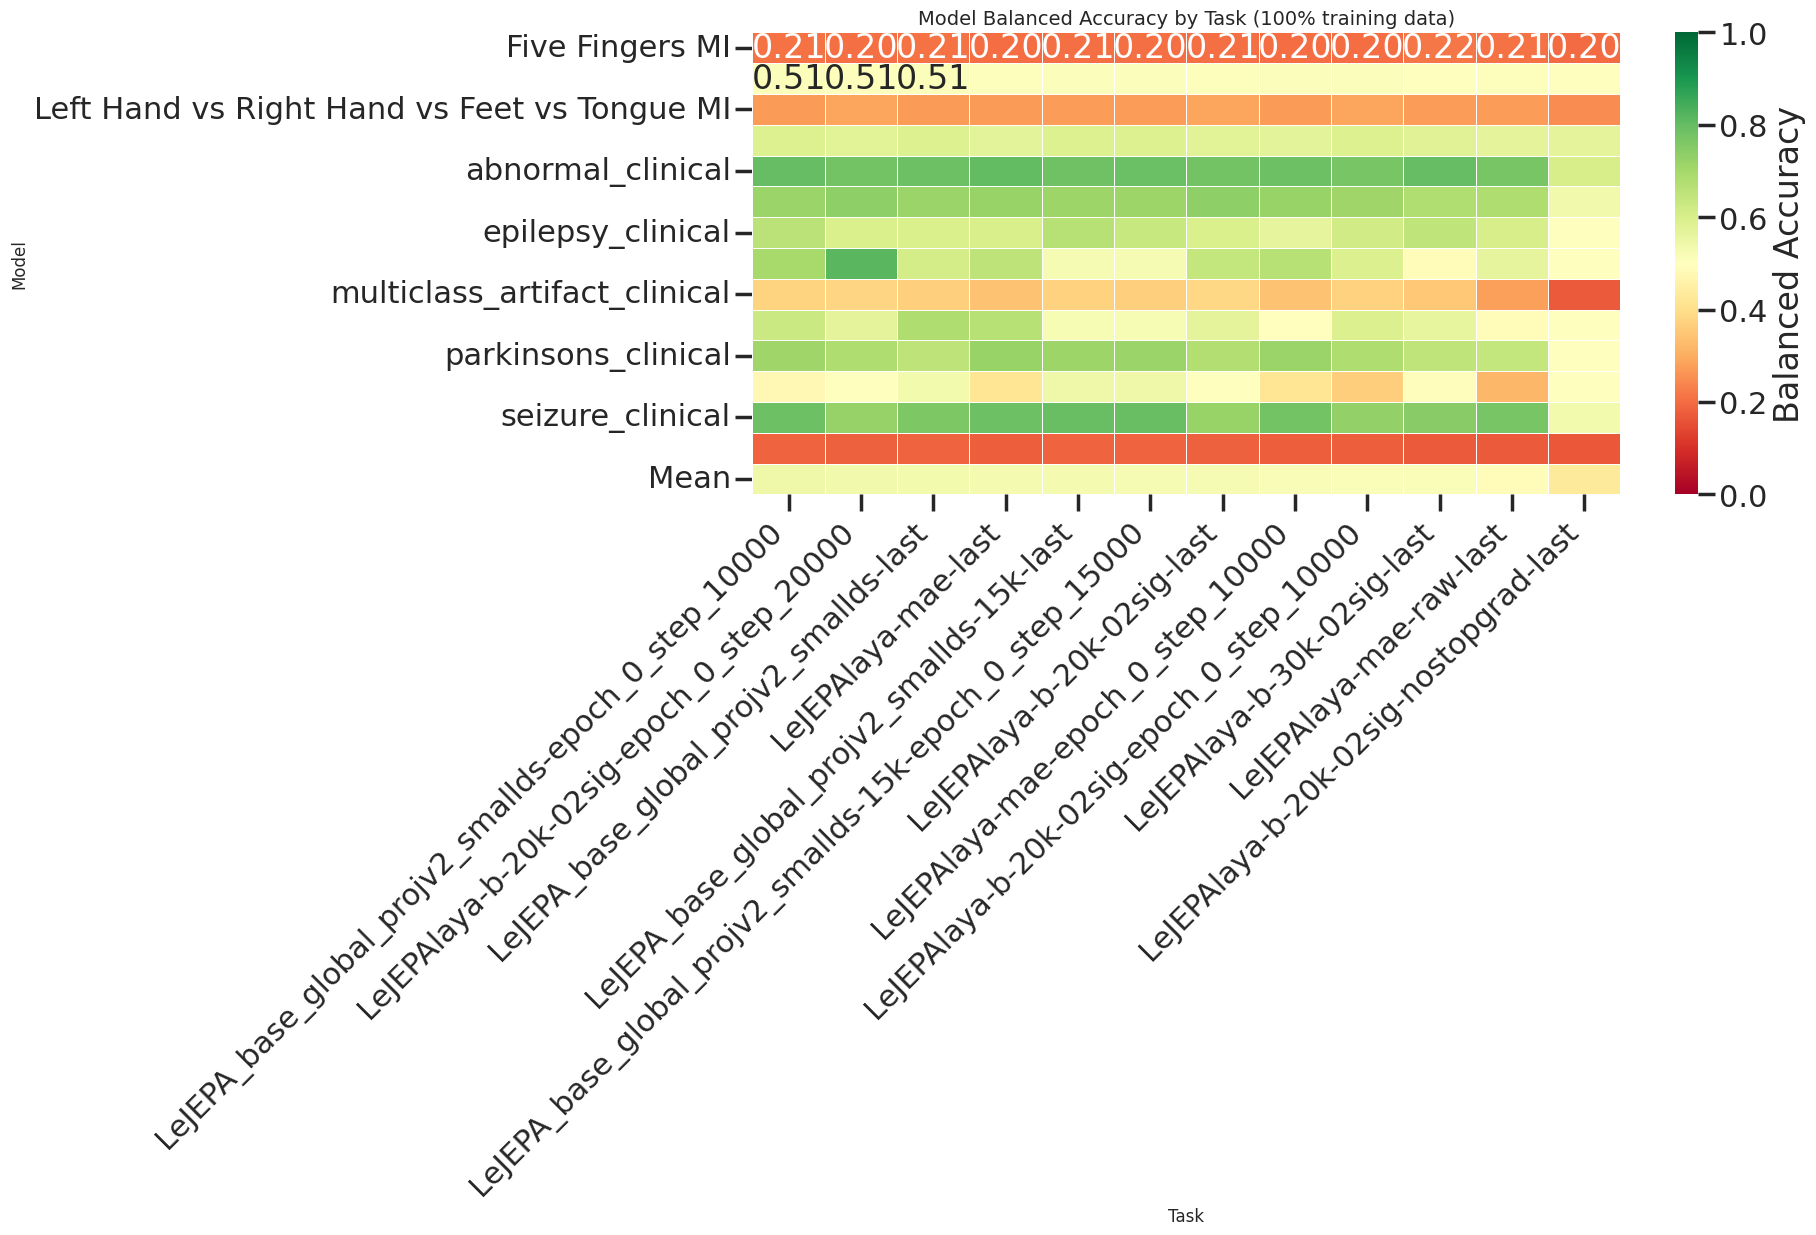

Saved to results/comparison_heatmap_balanced_accuracy.png


In [63]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [64]:
def best_model_per_task(df, percentage=1.0, metric="balanced_accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    max_acc = subset.groupby('task')['balanced_accuracy'].transform('max')
    best = subset[subset['balanced_accuracy'] == max_acc][['task', 'task_display', 'model_display', 'balanced_accuracy']].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [65]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_balanced_accuracy
386,Five Fingers MI,Five Fingers MI,LeJEPAlaya-b-30k-02sig,0.219683
442,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LeJEPAlaya-mae-raw,0.515301
505,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LeJEPAlaya-b-20k-02sig,0.296286
383,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LeJEPAlaya-b-20k-02sig,0.296286
159,Right Hand vs Feet MI,Right Hand vs Feet MI,LeJEPAlaya-b-20k-02sig,0.589770
181,abnormal_clinical,abnormal_clinical,LeJEPA_base_global_projv2_smallds,0.808254
63,binary_artifact_clinical,binary_artifact_clinical,LeJEPAlaya-b-20k-02sig,0.739034
670,binary_artifact_clinical,binary_artifact_clinical,LeJEPAlaya-b-20k-02sig,0.739034
628,epilepsy_clinical,epilepsy_clinical,LeJEPA_base_global_projv2_smallds-15k,0.692086
3,mtbi_clinical,mtbi_clinical,LeJEPAlaya-b-20k-02sig,0.836257


In [26]:
#what model has the most bests? 
w = best['model_display'].value_counts()
w

model_display
LeJEPAlaya-b-20k-02sig                   12
LeJEPA_base_global_projv2_smallds         4
LeJEPA_base_global_projv2_smallds-15k     3
LeJEPAlaya-mae                            3
LeJEPAlaya-mae-raw                        1
Name: count, dtype: int64

In [27]:
# def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
#     """Compute average rank of each model across tasks."""
#     subset = df[df["percentage"] == percentage].copy()
    
#     if len(subset) == 0:
#         return None
    
#     # Compute rank per task (1 = best)
#     subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
#     # Average rank per model
#     rankings = subset.groupby("model_display").agg({
#         "rank": "mean",
#         metric: "mean"
#     }).round(2)
    
#     rankings = rankings.sort_values("rank")
#     rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
#     return rankings

def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
    """Compute average rank of each model across tasks (only tasks with 2+ models)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Only include tasks that have multiple models
    task_model_counts = subset.groupby("task")["model_display"].nunique()
    tasks_with_multiple_models = task_model_counts[task_model_counts > 1].index
    print(len(tasks_with_multiple_models))
    subset = subset[subset["task"].isin(tasks_with_multiple_models)]
    
    if len(subset) == 0:
        print("No tasks with multiple models to rank")
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [28]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

14
Model Rankings (lower rank = better)


,Avg Rank,Avg Balanced_Accuracy
model_display,,
LeJEPA_base_global_projv2_smallds,19.97,0.54
LeJEPA_base_global_projv2_smallds-15k,21.76,0.53
LeJEPAlaya-b-20k-02sig,25.13,0.53
LeJEPAlaya-mae,26.95,0.53
LeJEPAlaya-mae-raw,36.77,0.49
LeJEPAlaya-b-20k-02sig-nostopgrad,45.41,0.44


## 5. BCI vs Clinical Comparison

In [29]:
df.groupby('task')['task_type'].first()

task
Five Fingers MI                                      BCI
Left Hand vs Right Hand MI                           BCI
Left Hand vs Right Hand vs Feet vs Tongue MI         BCI
Right Hand vs Feet MI                                BCI
abnormal_clinical                               Clinical
binary_artifact_clinical                        Clinical
epilepsy_clinical                               Clinical
mtbi_clinical                                   Clinical
multiclass_artifact_clinical                    Clinical
ocd_clinical                                    Clinical
parkinsons_clinical                             Clinical
schizophrenia_clinical                          Clinical
seizure_clinical                                Clinical
sleep_stages_clinical                           Clinical
Name: task_type, dtype: object

In [30]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="balanced_accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    # Group by model and task type
    comparison = subset.groupby(["model_display",  "step", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    return comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

In [31]:
# BCI vs Clinical comparison
if len(df) > 0:
    bci_vs_clinical = plot_bci_vs_clinical(df)


bci_vs_clinical.sort_values("Clinical", ascending=False)

task_type                                                      BCI  Clinical
model_display                         step                                  
LeJEPA_base_global_projv2_smallds     epoch_0_step_10000  0.394833  0.599183
LeJEPAlaya-b-20k-02sig                epoch_0_step_20000  0.404316  0.596523
LeJEPA_base_global_projv2_smallds     last                0.394833  0.589149
LeJEPAlaya-mae                        last                0.388358  0.588297
LeJEPA_base_global_projv2_smallds-15k last                0.378947  0.581720
                                      epoch_0_step_15000  0.383723  0.579224
LeJEPAlaya-b-20k-02sig                last                0.394651  0.578585
LeJEPAlaya-mae                        epoch_0_step_10000  0.405467  0.562051
LeJEPAlaya-b-20k-02sig                epoch_0_step_10000  0.396264  0.559862
LeJEPAlaya-mae-raw                    last                0.389872  0.528949
LeJEPAlaya-b-20k-02sig-nostopgrad     last                0.353198  0.467094

In [32]:
# #models to compares 
# models = [
#     ('LeJEPA_base_global_projv2_smallds', 'epoch_0_step_10000'), 
#     ('LeJEPAlaya-b-20k-02sig', 'epoch_0_step_20000')
#     ]

# model_compare_df = df[df.apply(lambda row: any(row['model_display'] == model and row['step'] == step for model, step in models), axis=1)]

# #stat test for each task
# from scipy.stats import ttest_ind
# for task in model_compare_df['task'].unique():
#     task_df = model_compare_df[model_compare_df['task'] == task]
#     if len(task_df['model_display'].unique()) < 2:
#         continue
#     group1 = task_df[task_df['model_display'] == models[0][0]][metric]
#     group2 = task_df[task_df['model_display'] == models[1][0]][metric]
#     stat, p = ttest_ind(group1, group2, equal_var=False)
#     print(f"Task: {task}, t-statistic: {stat:.3f}, p-value: {p:.3f}")


In [33]:
import numpy as np
import pandas as pd
from itertools import product, combinations
from scipy.stats import friedmanchisquare

# arbitrary N models
models = [
    ("LeJEPA_base_global_projv2_smallds", "epoch_0_step_10000"),
    ("LeJEPAlaya-b-20k-02sig", "epoch_0_step_20000"),
    ("LeJEPAlaya-b-20k-02sig-nostopgrad	", "last"),
]

alpha = 0.05  # per-task omnibus threshold

def paired_exact_permutation_pvalue(x, y):
    d = np.asarray(x) - np.asarray(y)
    d = d[~np.isnan(d)]
    n = len(d)
    if n == 0:
        return np.nan, np.nan
    obs = d.mean()
    signs = np.array(list(product([-1, 1], repeat=n)), dtype=float)  # exact (2^n)
    means = (signs * d).mean(axis=1)
    p = np.mean(np.abs(means) >= abs(obs))
    return obs, p

def run_per_task_model_comparison_no_correction(df, metric, models, alpha=0.05):
    compare_df = df[
        df.apply(
            lambda row: any(
                (row["model_display"] == m and row["step"] == s)
                for m, s in models
            ),
            axis=1,
        )
    ].copy()

    omnibus_rows = []
    pairwise_rows = []

    for task in sorted(compare_df["task"].unique()):
        task_df = compare_df[compare_df["task"] == task]

        # align seeds so tests are paired
        pivot = task_df.pivot_table(
            index="seed",
            columns=["model_display", "step"],
            values=metric,
            aggfunc="mean",
        )

        available = [ms for ms in models if ms in pivot.columns]
        if len(available) < 2:
            continue

        paired = pivot[available].dropna()
        n_seeds = len(paired)
        if n_seeds < 2:
            continue

        # omnibus only for >=3 models
        if len(available) >= 3:
            arrs = [paired[c].values for c in available]
            stat, p_omni = friedmanchisquare(*arrs)
            omnibus_test = "friedman"
            run_pairwise = p_omni < alpha
        else:
            stat, p_omni = np.nan, np.nan
            omnibus_test = "none_2_models"
            run_pairwise = True

        omnibus_rows.append({
            "task": task,
            "n_models": len(available),
            "n_paired_seeds": n_seeds,
            "omnibus_test": omnibus_test,
            "omnibus_stat": stat,
            "omnibus_p": p_omni,
        })

        if not run_pairwise:
            continue

        for a, b in combinations(available, 2):
            eff, p = paired_exact_permutation_pvalue(paired[a].values, paired[b].values)
            pairwise_rows.append({
                "task": task,
                "n_paired_seeds": n_seeds,
                "left_model": a[0],
                "left_step": a[1],
                "right_model": b[0],
                "right_step": b[1],
                "mean_diff_left_minus_right": eff,
                "p_raw": p,  # no correction
            })

    omnibus_df = pd.DataFrame(omnibus_rows).sort_values("task")
    pairwise_df = pd.DataFrame(pairwise_rows).sort_values(["task", "p_raw"])
    return omnibus_df, pairwise_df

omnibus_df, pairwise_df = run_per_task_model_comparison_no_correction(
    df=df, metric=metric, models=models, alpha=alpha
)

print("\n=== Omnibus per task ===")
print(omnibus_df.to_string(index=False))

print("\n=== Pairwise per task (raw p-values, no correction) ===")
print(pairwise_df.to_string(index=False))



=== Omnibus per task ===
                                        task  n_models  n_paired_seeds  omnibus_test  omnibus_stat  omnibus_p
                             Five Fingers MI         2               4 none_2_models           NaN        NaN
                  Left Hand vs Right Hand MI         2               5 none_2_models           NaN        NaN
Left Hand vs Right Hand vs Feet vs Tongue MI         2               5 none_2_models           NaN        NaN
                       Right Hand vs Feet MI         2               5 none_2_models           NaN        NaN
                           abnormal_clinical         2               5 none_2_models           NaN        NaN
                    binary_artifact_clinical         2               5 none_2_models           NaN        NaN
                           epilepsy_clinical         2               5 none_2_models           NaN        NaN
                               mtbi_clinical         2               5 none_2_models          

## 6. Export Results

In [34]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Saved numeric tables to tables/model_comparison_balanced_accuracy_mean.csv and _std.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

<Axes: >

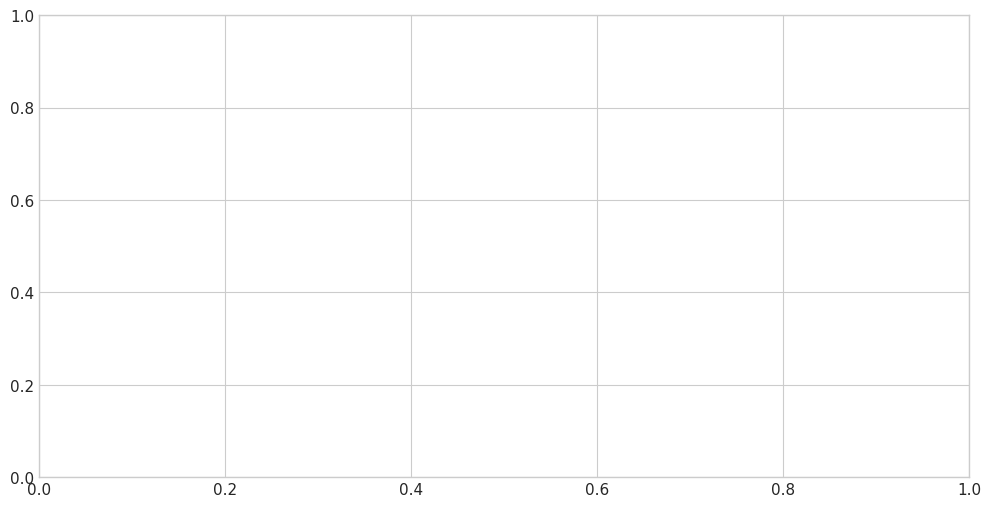

In [35]:
laya_b_og = df[df['model_display'] == 'LeJEPA_base_global_projv2_02sig_FULL_v0']
laya_b_og_v2 = df[df['model_display'] == 'LeJEPA_base_global_projv2_02sig_FULL_v2']

laya_b_og['step'] = laya_b_og['step'].str.replace('epoch_0_step_', '').str.replace('last', '50000').astype(int)
laya_b_og_v2['step'] = laya_b_og_v2['step'].str.replace('epoch_0_step_', '').str.replace('last', '100000').astype(int)

laya_b_og = pd.concat([laya_b_og, laya_b_og_v2], ignore_index=True)
# print(laya_b_og.groupby(['step', 'task_display']).size().min())
sns.lineplot(data=laya_b_og, x='step', y='balanced_accuracy', hue='task_type', marker='o')

In [36]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)

## Additional Experiments: Noise Robustness

All plots above use clean-only results. This section visualizes the noise sweeps.


In [37]:
df_for_noiseplot = df_combined[(df_combined["percentage"] == 1.0)]
clean_baseline = df_for_noiseplot[df_for_noiseplot["is_clean"]].groupby("model_display")["balanced_accuracy"].mean()

In [38]:
noise_to_plot  = df_for_noiseplot[~df_for_noiseplot["is_clean"]].sort_values("noise_snr_db", ascending=False)
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].fillna(noise_to_plot['noise_types'])
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].replace('gaussian+one_over_f+emg+channel_dropout', 'all')
noise_to_plot['model_display'] = noise_to_plot['model_display'].str.split('_noise').apply(lambda x: x[0])

In [39]:
noise_to_plot['task_display'] = noise_to_plot['task_display'].str.replace('_clinical', '').str.replace('_', ' ').str.capitalize()

In [40]:
for task in noise_to_plot['task'].unique():
    plt.figure(figsize=(10, 6))
    task_data = noise_to_plot[noise_to_plot['task'] == task]
    task_data = task_data[task_data['noise_types_str'] == 'all']
    task_data = task_data[~task_data['model_display'].str.contains('20')]
    task_data = task_data[task_data['noise_snr_db'] >= 0]
    sns.lineplot(
        data=task_data,
        x="noise_snr_db",
        y="balanced_accuracy",
        hue="model_display",
        hue_order=list(model_colors.keys()),
        palette=model_colors,
        marker="o"
    )
    plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)
    plt.title(f"{task_data['task_display'].iloc[0]}") #Noise Robustness on Task: 
    plt.xlabel("Noise SNR (dB)")
    plt.ylabel("Balanced Accuracy")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend(title="Model", fontsize=10)
    plt.tight_layout()
    plt.show()

In [41]:
noise_to_plot['task'].unique()

array([], dtype=object)

/tmp/ipykernel_1199062/2496255945.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


IndexError: single positional indexer is out-of-bounds

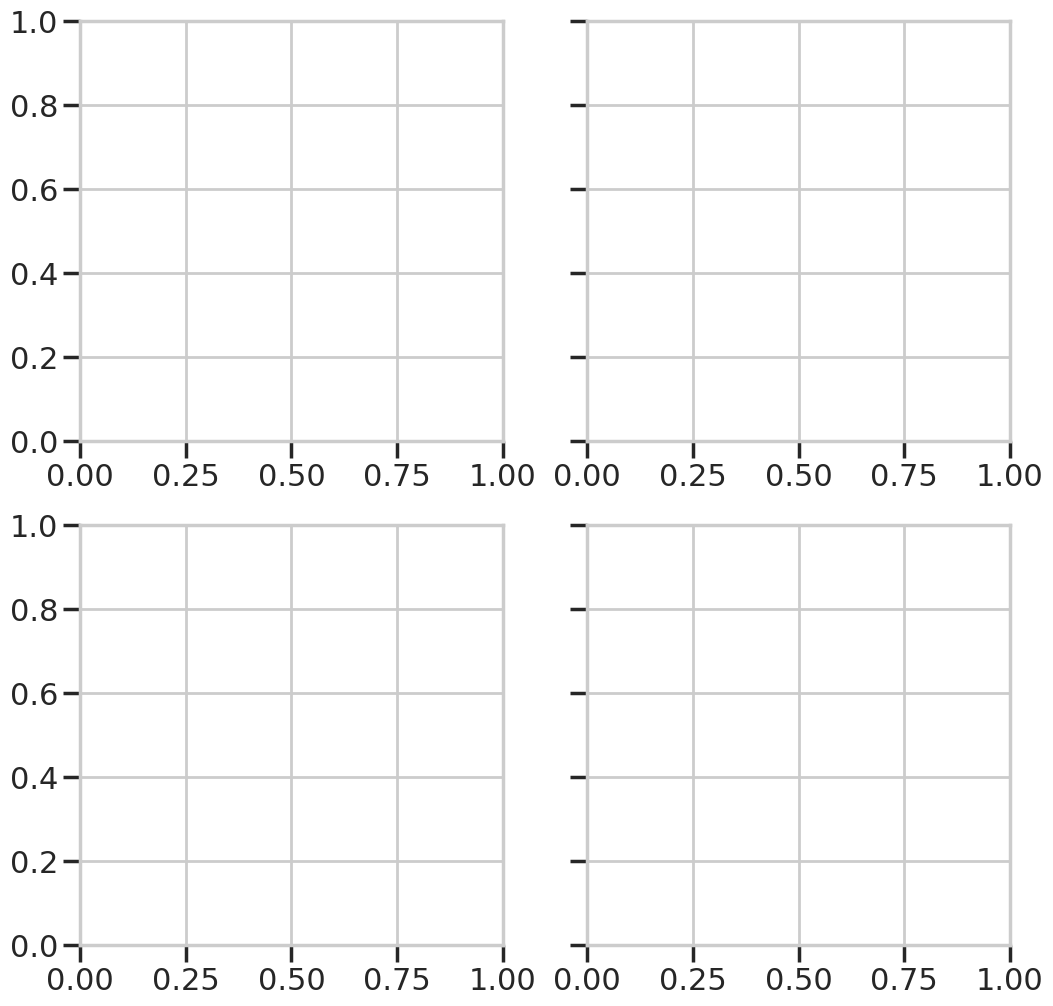

In [42]:
#PAPER FIGURE!
sns.set_context('poster')
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=False, sharey=True)
for i, task in enumerate(['abnormal_clinical', 'epilepsy_clinical', 'parkinsons_clinical', 'seizure_clinical']):
    task_data = noise_to_plot[noise_to_plot['task'] == task]
    task_data = task_data[task_data['noise_types_str'] == 'all']
    task_data = task_data[~task_data['model_display'].str.contains('20')]
    task_data = task_data[task_data['noise_snr_db'] >= 0]
    ax = axes.flatten()[i]
    sns.lineplot(
        data=task_data,
        x="noise_snr_db",
        y="balanced_accuracy",
        hue="model_display",
        hue_order=list(model_colors.keys()),
        palette=model_colors,
        marker="o",
        ax=ax
    )
    ax.set_title(f"{task_data['task_display'].iloc[0]}") #Noise Robustness on Task: 
    ax.set_xlabel("Noise SNR (dB)")
    ax.set_ylabel("Balanced Accuracy")
    ax.set_ylim(.2, 1)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(title="Model")
    else:
        ax.get_legend().remove()
    ax.invert_xaxis()

plt.tight_layout()
plt.savefig("figures/noise_robustness_clinical_tasks.png", dpi=300, bbox_inches="tight")

In [ ]:
df_all['probe_type'].unique()

In [ ]:

#Show results for attentive probe
attentive = df_all[df_all['probe_type'] == 'attentive']
attentive = attentive[attentive['is_clean']]

attentive.groupby(['model_display', 'task'])['balanced_accuracy'].mean().sort_values(ascending=False)

In [ ]:
import math
import seaborn as sns
import matplotlib.pyplot as plt

# Filter once
plot_df = noise_to_plot.copy()
plot_df = plot_df[~plot_df["model_display"].str.contains("20", na=False)]
plot_df = plot_df[plot_df["noise_snr_db"] >= 0]

for task, task_data in plot_df.groupby("task"):
    task_display = task_data["task_display"].iloc[0]
    noise_types = sorted(task_data["noise_types_str"].unique())
    #skip if not all models have not all noise types
    models_in_task = task_data["model_display"].unique()
    skip = False
    for model in models_in_task:
        model_data = task_data[task_data["model_display"] == model]
        model_noise_types = model_data["noise_types_str"].unique()
        if set(model_noise_types) != set(noise_types):
            skip = True
            break
    if skip:
        continue

    n = len(noise_types)
    cols = min(3, n)
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows), sharey=True, sharex=True)
    axes = axes.flatten() if n > 1 else [axes]

    for ax, nt in zip(axes, noise_types):
        sub = task_data[task_data["noise_types_str"] == nt]
        sns.lineplot(
            data=sub,
            x="noise_snr_db",
            y="balanced_accuracy",
            hue="model_display",
            hue_order=list(model_colors.keys()),
            palette=model_colors,
            marker="o",
            ax=ax
        )
        ax.invert_xaxis()
        ax.set_title(nt)
        ax.set_xlabel("Noise SNR (dB)")
        ax.set_ylabel("Balanced Accuracy")
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.legend().remove()

    # Remove empty axes if any
    for ax in axes[len(noise_types):]:
        ax.remove()

    # Single shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

    fig.suptitle(task_display, y=1.02)
    fig.tight_layout()
    plt.savefig(f"figures/noise/noise_robustness_{task}.png", dpi=300, bbox_inches="tight")
    plt.show()
